In [31]:
# Data manipulation
import pandas as pd
import numpy as np

# Modelling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Visualisation
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns

## 1. Exploratory Data Analysis

We analyse the **Student Performance Factors** dataset, covering variable structure, missing data, and relationships with the target variable `Exam_Score`. Two analytical tracks are derived based on the missing data findings:

- **Track A (Imputed):** All rows are retained; missing values in three categorical columns are filled by training-set mode imputation.
- **Track B (Dropped):** Rows with any missing values are removed via listwise deletion.

### 1.1 Data Loading

In [32]:
df = pd.read_csv("../data/StudentPerformanceFactors.csv")

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("Features List:")
print(*df.columns, sep=", ")

Dataset Shape: 6607 rows, 20 columns
Features List:
Hours_Studied, Attendance, Parental_Involvement, Access_to_Resources, Extracurricular_Activities, Sleep_Hours, Previous_Scores, Motivation_Level, Internet_Access, Tutoring_Sessions, Family_Income, Teacher_Quality, School_Type, Peer_Influence, Physical_Activity, Learning_Disabilities, Parental_Education_Level, Distance_from_Home, Gender, Exam_Score


### 1.2 Data Validation and Cleaning

Before addressing missing values, a data integrity check identifies logically impossible entries — such as numerical scores outside their valid range or negative values — and verifies that all categorical variables contain recognised labels. This guards against data-entry errors that would otherwise bias subsequent regression estimates.

In [33]:
# Check: Numerical attributes invalid entries
audit_results = {
    "Exam_Score > 100": len(df[df['Exam_Score'] > 100]),
    "Attendance > 100%": len(df[df['Attendance'] > 100]),
    "Previous_Scores > 100": len(df[df['Previous_Scores'] > 100]),
    "Sleep_Hours > 24": len(df[df['Sleep_Hours'] > 24]),
    "Any Negative Values": (df.select_dtypes(include=[np.number]) < 0).sum().sum()
}

for issue, count in audit_results.items():
    print(f"{issue}: {count}")

Exam_Score > 100: 1
Attendance > 100%: 0
Previous_Scores > 100: 0
Sleep_Hours > 24: 0
Any Negative Values: 0


In [34]:
# Check: categorical attributes invalid entries
cat_cols = df.select_dtypes(include=['object']).columns

cat_summary = []
for col in cat_cols:
    unique_vals = df[col].dropna().unique()
    cat_summary.append({
        "Attribute": col,
        "Unique Values": ", ".join(map(str, unique_vals)),
        "Count": len(unique_vals)
    })

display(pd.DataFrame(cat_summary))

,Attribute,Unique Values,Count
0,Parental_Involvement,"Low, Medium, High",3
1,Access_to_Resources,"High, Medium, Low",3
2,Extracurricular_Activities,"No, Yes",2
3,Motivation_Level,"Low, Medium, High",3
4,Internet_Access,"Yes, No",2
5,Family_Income,"Low, Medium, High",3
6,Teacher_Quality,"Medium, High, Low",3
7,School_Type,"Public, Private",2
8,Peer_Influence,"Positive, Negative, Neutral",3
9,Learning_Disabilities,"No, Yes",2


In [35]:
# Remove impossible scores (only the row with score 101)
df = df[df["Exam_Score"] <= 100].copy()

The check identified one anomalous observation (`Exam_Score` = 101), which exceeds the theoretical maximum and was removed. All other numerical predictors lie within plausible academic and physical ranges.

Categorical validation confirms that all nominal and ordinal variables contain recognised labels. With at most three distinct levels per feature ($n \le 3$), one-hot encoding produces a compact and well-defined set of binary indicators.

#### 1.2.1 Missing Data Strategy

In [36]:
missing = df.isna().sum()
missing_table = pd.DataFrame({
    "Dtype": df.dtypes,
    "Count": missing,
    "Proportion": (missing / len(df)).round(4),
    "Percentage (%)": (missing / len(df) * 100).round(2)
}).sort_values("Count", ascending=False)

# Display only rows with missing values
display(missing_table[missing_table["Count"] > 0])

,Dtype,Count,Proportion,Percentage (%)
Parental_Education_Level,object,90,0.0136,1.36
Teacher_Quality,object,78,0.0118,1.18
Distance_from_Home,object,67,0.0101,1.01


All three variables with missing values are categorical, making **mode imputation** a natural choice. As the row-wise summary below shows, only 3.47% of observations have any missing entry, so **listwise deletion** is equally viable with negligible data loss. We therefore proceed with both strategies in parallel.

In [37]:
# Row-wise (Observation) Missing Data Summary
row_missing_counts = df.isna().sum(axis=1).value_counts().sort_index()

row_missing_summary = pd.DataFrame({
    "Count": row_missing_counts,
    "Proportion": (row_missing_counts / len(df)).round(4),
    "Percentage (%)": (row_missing_counts / len(df) * 100).round(2)
}, index=row_missing_counts.index)

row_missing_summary.index.name = "Missing Values per Row"

display(row_missing_summary)

,Count,Proportion,Percentage (%)
Missing Values per Row,,,
0,6377,0.9653,96.53
1,223,0.0338,3.38
2,6,0.0009,0.09


The vast majority of observations (96.53%) contain no missing values, and only 0.09% have more than one missing entry. Dropping rows with missing values therefore retains 96.53% of the data, making listwise deletion a low-cost alternative to imputation.

In [38]:
# Track A: retain all rows (imputation applied later, within the train split)
df_imputed = df.copy()

# Track B: drop rows with any missing value in the identified columns
df_dropped = df.dropna(subset=["Parental_Education_Level", "Teacher_Quality", "Distance_from_Home"])

rows_lost = df.shape[0] - df_dropped.shape[0]
print(f"Track A (Imputed) shape: {df_imputed.shape}")
print(f"Track B (Dropped) shape: {df_dropped.shape}  ({rows_lost} rows removed)")

Track A (Imputed) shape: (6606, 20)
Track B (Dropped) shape: (6377, 20)  (229 rows removed)


### 1.3 Descriptive Statistics

In [39]:
# Create a clean two-column summary table
dtype_summary = df.dtypes.to_frame(name="Data Type")
dtype_summary.index.name = "Variable"

# Sort by type
display(dtype_summary.sort_values("Data Type"))

,Data Type
Variable,
Hours_Studied,int64
Physical_Activity,int64
Previous_Scores,int64
Sleep_Hours,int64
Tutoring_Sessions,int64
Attendance,int64
Exam_Score,int64
Access_to_Resources,object
Parental_Involvement,object


The dataset contains seven continuous numerical variables — `Hours_Studied`, `Physical_Activity`, `Previous_Scores`, `Sleep_Hours`, `Tutoring_Sessions`, `Attendance`, and `Exam_Score` — with the remaining twelve being categorical.

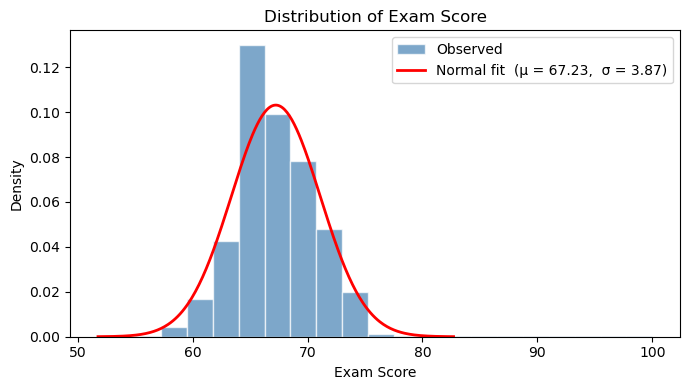

In [40]:
mu = df["Exam_Score"].mean()
sig = df["Exam_Score"].std()
x = np.linspace(mu - 4*sig, mu + 4*sig, 300)
pdf = (1 / (sig * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sig) ** 2)

fig, ax = subplots(figsize=(7, 4))
ax.hist(df["Exam_Score"], bins=20, density=True,
        color="steelblue", alpha=0.7, edgecolor="white", label="Observed")
ax.plot(x, pdf, "r-", linewidth=2,
        label=f"Normal fit  (μ = {mu:.2f},  σ = {sig:.2f})")
ax.set_title("Distribution of Exam Score")
ax.set_xlabel("Exam Score")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()

In [41]:
desc_stats = df.describe().T[["mean", "std", "min", "50%", "max"]]
desc_stats["CV"] = df.std(numeric_only=True) / df.mean(numeric_only=True)
desc_stats["Skewness"] = df.skew(numeric_only=True)

desc_stats.columns = ["Mean", "Std Dev", "Min", "Median", "Max", "CV", "Skewness"]

desc_stats = desc_stats.round({
    "Mean": 2, "Std Dev": 2, "Min": 0, "Median": 1, "Max": 0,
    "CV": 3, "Skewness": 2
})

display(desc_stats.sort_values(by="CV", ascending=False))

,Mean,Std Dev,Min,Median,Max,CV,Skewness
Variable,,,,,,,
Tutoring_Sessions,1.49,1.23,0.0,1.0,8.0,0.824,0.81
Physical_Activity,2.97,1.03,0.0,3.0,6.0,0.348,-0.03
Hours_Studied,19.97,5.99,1.0,20.0,44.0,0.300,0.01
Sleep_Hours,7.03,1.47,4.0,7.0,10.0,0.209,-0.02
Previous_Scores,75.07,14.40,50.0,75.0,100.0,0.192,-0.00
Attendance,79.97,11.55,60.0,80.0,100.0,0.144,0.01
Exam_Score,67.23,3.87,55.0,67.0,100.0,0.058,1.58


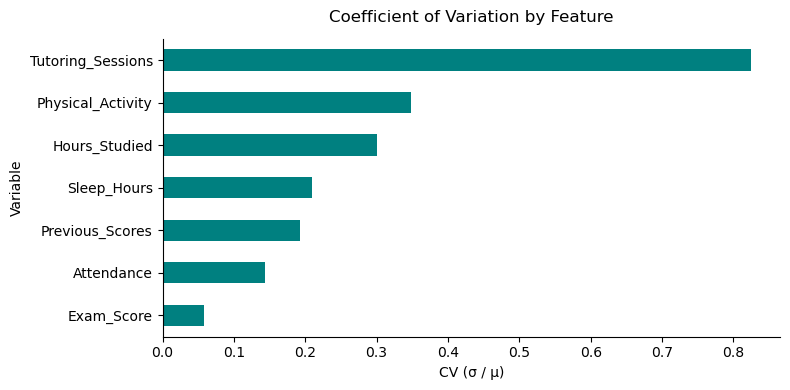

In [42]:
fig, ax = subplots(figsize=(8, 4))
desc_stats["CV"].sort_values().plot(kind="barh", color="teal", ax=ax)

ax.set_title("Coefficient of Variation by Feature", fontsize=12, pad=12)
ax.set_xlabel("CV (σ / μ)")
ax.set_ylabel("Variable")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

`Exam_Score` is approximately normally distributed across its central range but exhibits a positive right-skew (skewness = 1.64), driven by a sparse tail of high-scoring students. Accordingly, the mean (μ = 67.24) lies just above the median (67.0), whilst the bulk of students score between 60 and 75.

The Coefficient of Variation (CV = σ/μ) provides a scale-free measure of relative dispersion across predictors. Behavioural features — `Tutoring_Sessions` (CV = 0.824) and `Physical_Activity` (CV = 0.347) — exhibit the greatest relative variability, reflecting marked heterogeneity in student habits. Academic metrics such as `Attendance` (CV = 0.144) are considerably more stable. This contrast suggests that behavioural variables may offer stronger discriminatory power in modelling than more homogeneous academic measures.

### 1.4 Correlation with Target

Pearson correlations between each numerical predictor and `Exam_Score`, computed separately for Track A and Track B.

In [43]:
corr_A = df.corr(numeric_only=True)["Exam_Score"]
corr_B = df_dropped.corr(numeric_only=True)["Exam_Score"]

corr_comp = pd.concat([
    corr_A.rename("Track A (Imputed)"),
    corr_B.rename("Track B (Dropped)")
], axis=1)
corr_comp['Difference'] = (corr_comp.iloc[:, 1] - corr_comp.iloc[:, 0])

display(corr_comp.sort_values(by="Track A (Imputed)").round(3))

,Track A (Imputed),Track B (Dropped),Difference
Variable,,,
Sleep_Hours,-0.016,-0.016,-0.000
Physical_Activity,0.028,0.025,-0.003
Tutoring_Sessions,0.154,0.154,0.000
Previous_Scores,0.174,0.174,-0.001
Hours_Studied,0.447,0.446,-0.000
Attendance,0.582,0.582,-0.001
Exam_Score,1.000,1.000,0.000


`Attendance` (~0.58) and `Hours_Studied` (~0.45) are the strongest predictors in both tracks. `Sleep_Hours` and `Physical_Activity` are near zero. Correlation coefficients are nearly identical across tracks, confirming that the small number of dropped rows has negligible impact on the linear signal.

## 2. Data Preprocessing

Both tracks undergo the same pipeline: 80/20 train–test split (`random_state = 42`), missing-value treatment, and one-hot encoding of categorical variables. The response variable is defined below; all preprocessing is applied to each track independently to prevent any cross-contamination of information.

In [44]:
TARGET = "Exam_Score"

### 2.1 Track A — Mode Imputation

The full 6,607-row dataset (NaNs retained) is split 80/20 before any imputation. The mode of each missing categorical column is computed on the training partition only and then applied to the test set, preventing leakage of test-set information into the imputation step. One-hot encoding follows with `drop_first = True` to avoid perfect multicollinearity; the encoded columns are subsequently aligned between train and test to handle any unseen categories in the test fold.

In [45]:
X_a = df_imputed.drop(TARGET, axis=1)
y_a = df_imputed[TARGET]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42
)

# Mode Imputation (Loop Method; prevents data leakage)
cat_missing = ["Parental_Education_Level", "Teacher_Quality", "Distance_from_Home"]

for col in cat_missing:
    mode_value = X_train_a[col].mode()[0]      
    X_train_a[col] = X_train_a[col].fillna(mode_value)
    X_test_a[col] = X_test_a[col].fillna(mode_value)

# Categorical Encoding
X_train_a_enc = pd.get_dummies(X_train_a, drop_first=True)
X_test_a_enc = pd.get_dummies(X_test_a, drop_first=True)

# Align train and test so they have the same columns
X_train_a_enc, X_test_a_enc = X_train_a_enc.align(X_test_a_enc, join="left", axis=1, fill_value=0)

### 2.2 Track B — Listwise Deletion

The 6,378 complete-case rows are split 80/20 and one-hot encoded identically to Track A. No imputation is required; column alignment is applied for consistency.

In [46]:
X_b = df_dropped.drop(TARGET, axis=1)
y_b = df_dropped[TARGET]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42
)

# Categorical Encoding
X_train_b_enc = pd.get_dummies(X_train_b, drop_first=True)
X_test_b_enc = pd.get_dummies(X_test_b, drop_first=True)

# Align to ensure consistent columns across train and test
X_train_b_enc, X_test_b_enc = X_train_b_enc.align(X_test_b_enc, join="left", axis=1, fill_value=0)

In [48]:
comparison_summary = pd.DataFrame({
    "Track A": [X_train_a_enc.shape[0], X_test_a_enc.shape[0], X_train_a_enc.shape[1]],
    "Track B": [X_train_b_enc.shape[0], X_test_b_enc.shape[0], X_train_b_enc.shape[1]]
}, index=["Training observations", "Test observations", "Encoded features"])

comparison_summary.index.name = "Dataset Metric"
display(comparison_summary)

# check
print(f"\nFeature names match: {list(X_train_a_enc.columns) == list(X_train_b_enc.columns)}")

,Track A,Track B
Dataset Metric,,
Training observations,5284,5101
Test observations,1322,1276
Encoded features,27,27



Feature names match: True


### 2.3 Full-Dataset Construction

The train and test partitions are recombined per track to form the full encoded datasets used for 10-fold cross-validation. For Track A, imputation parameters were derived from the original 80% training split; because the mode of categorical variables is highly stable across re-samples, the effect on cross-validation estimates is expected to be negligible.

In [49]:
X_full_a_enc = pd.concat([X_train_a_enc, X_test_a_enc]).reset_index(drop=True)
y_full_a = pd.concat([y_train_a, y_test_a]).reset_index(drop=True)

X_full_b_enc = pd.concat([X_train_b_enc, X_test_b_enc]).reset_index(drop=True)
y_full_b = pd.concat([y_train_b, y_test_b]).reset_index(drop=True)

print(f"Track A — full: {X_full_a_enc.shape[0]:,} obs, {X_full_a_enc.shape[1]} features")
print(f"Track B — full: {X_full_b_enc.shape[0]:,} obs, {X_full_b_enc.shape[1]} features")

Track A — full: 6,606 obs, 27 features
Track B — full: 6,377 obs, 27 features


## 3. Global Regression Models

### 3.1 Null Model (Intercept-only Baseline)

A null model (intercept-only) predicts the training-set mean for every observation, $\hat{Y}_i = \bar{Y}_{\text{train}}$.  This is the simplest possible model and establishes a performance floor: any model that cannot beat this RMSE offers no useful predictive signal.


### Fitting Multiple Linear Regression 

We fit Multiple Linear Regression models to both experimental tracks to evaluate if the missing data handling strategy (Imputation vs. Deletion) significantly alters the model's coefficients or predictive performance.

#### Track A: Imputed Dataset

For Track A, missing categorical values were filled using the training-set mode (Loop Method) to preserve the original sample size of 6,607 observations while avoiding data leakage.

In [ ]:
lr_a = LinearRegression()
lr_a.fit(X_train_a_enc, y_train_a)

# Initial Hold-out estimate
# Train-Test Evaluation for Track A
pred_train_a = lr_a.predict(X_train_a_enc)
pred_test_a = lr_a.predict(X_test_a_enc)
rmse_train_a = np.sqrt(mean_squared_error(y_train_a, pred_train_a))
rmse_test_a = np.sqrt(mean_squared_error(y_test_a, pred_test_a))

# Combine the cleaned and encoded training/test sets
X_full_a_enc = pd.concat([X_train_a_enc, X_test_a_enc]).reset_index(drop=True)
y_full_a = pd.concat([y_train_a, y_test_a]).reset_index(drop=True)

# 10-Fold Cross-Validation on combined cleaned data
cv_lr_a = cross_validate(lr_a, X_full_a_enc, y_full_a, cv=10, scoring="neg_root_mean_squared_error")
rmse_cv_a = -cv_lr_a["test_score"].mean()
std_cv_a = cv_lr_a["test_score"].std()

print(f"Track A - Training RMSE: {rmse_train_a:.2f}")
print(f"Track A - Test RMSE: {rmse_test_a:.2f}")

print(f"Track A - Hold-out RMSE: {rmse_test_a:.3f}")
print(f"Track A - CV Mean RMSE: {rmse_cv_a:.3f} (s.d. {std_cv_a:.3f})")


#### Track B: Dropped Dataset (Listwise Deletion)

For Track B, observations containing missing values were removed, resulting in a dataset of 6,378 complete entries. This serves as a "pure data" baseline.

In [ ]:
lr_b = LinearRegression()
lr_b.fit(X_train_b_enc, y_train_b)

# Initial Hold-out estimate
# Train-Test Evaluation for Track B
pred_train_b = lr_b.predict(X_train_b_enc)
pred_test_b = lr_b.predict(X_test_b_enc)
rmse_train_b = np.sqrt(mean_squared_error(y_train_b, pred_train_b))
rmse_test_b = np.sqrt(mean_squared_error(y_test_b, pred_test_b))

# Combine the encoded training/test sets for the dropped track
X_full_b_enc = pd.concat([X_train_b_enc, X_test_b_enc]).reset_index(drop=True)
y_full_b = pd.concat([y_train_b, y_test_b]).reset_index(drop=True)

# 10-Fold Cross-Validation on combined data
cv_lr_b = cross_validate(lr_b, X_full_b_enc, y_full_b, cv=10, scoring="neg_root_mean_squared_error")
rmse_cv_b = -cv_lr_b["test_score"].mean()
std_cv_b = cv_lr_b["test_score"].std()

print(f"Track B - Training RMSE: {rmse_train_b:.2f}")
print(f"Track B - Test RMSE: {rmse_test_b:.2f}")

print(f"Track B - Hold-out RMSE: {rmse_test_b:.3f}")
print(f"Track B - CV Mean RMSE: {rmse_cv_b:.3f} (s.d. {std_cv_b:.3f})")

For both tracks, the training and test RMSE remain closely aligned (e.g., 2.09 vs 1.80 in Track A). This consistency suggests that our models are not overfitting and are successfully capturing the underlying signal within the data.

Track A (Imputed) achieved a lower 10-fold CV RMSE (1.961) compared to Track B (2.049). This suggests that retaining the full sample size through mode imputation preserves a stronger predictive signal.

Track B (Dropped) exhibited significantly lower variance, with a standard deviation of 0.330 compared to 0.569 for Track A. This indicates that listwise deletion, while slightly less accurate, produces a more consistent model across different data partitions.

While Track A offers better raw performance, Track B's higher stability and reliance on pure (non-synthetic) data make it a robust baseline for final model selection.

#### Diagnostic Plots

In [ ]:
fig, ax = subplots(figsize=(6, 6))

ax.scatter(y_test_a, pred_test_a)
ax.set_xlabel("Actual Exam_Score (y_test)")
ax.set_ylabel("Predicted Exam_Score (pred_test)")
ax.set_title("Track A (Imputed): Actual vs. Predicted Performance")

# 45-degree line
minv = min(y_test_a.min(), pred_test_a.min())
maxv = max(y_test_a.max(), pred_test_a.max())
ax.plot([minv, maxv], [minv, maxv], "--")

In [ ]:
fig, ax = subplots(figsize=(6, 6))

ax.scatter(y_test_b, pred_test_b)
ax.set_xlabel("Actual Exam_Score (y_test)")
ax.set_ylabel("Predicted Exam_Score (pred_test)")
ax.set_title("Track B (Dropped): Actual vs. Predicted Performance")

# 45-degree line
minv = min(y_test_b.min(), pred_test_b.min())
maxv = max(y_test_b.max(), pred_test_b.max())
ax.plot([minv, maxv], [minv, maxv], "--")

In [ ]:
resid = y_test_a - pred_test_a

fig, ax = subplots(figsize=(6, 4))
ax.scatter(pred_test_a, resid)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted Exam_Score")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Track A (Imputed): Prediction Error Analysis")

In [ ]:
resid = y_test_b - pred_test_b

fig, ax = subplots(figsize=(6, 4))
ax.scatter(pred_test_b, resid)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted Exam_Score")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Track B (Dropped): Prediction Error Analysis")

In both tracks, the residual and "Actual vs. Predicted" plots show significant deviation for high exam scores. This confirms that the model systemically underpredicts top-performing students.

The diagnostic plots suggest that while the model performs well for mid-range scores, it tends to underpredict students with very high exam scores. This indicates potential model bias in the upper tail.

## 4. Tree-based Models


### Fitting Decision Tree Regressor

To capture potential non-linear relationships and feature interactions that a linear model may miss, we next fit a decision tree regressor on both Track A (imputed) and Track B (dropped), mirroring the structure of the linear regression section.

#### Track A (Imputed): Constrained tree (max_depth = 3)

We begin with a shallow tree to control model complexity and reduce overfitting.

In [ ]:
tree_a_depth3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_a_depth3.fit(X_train_a_enc, y_train_a)

pred_train_a_tree3 = tree_a_depth3.predict(X_train_a_enc)
pred_test_a_tree3  = tree_a_depth3.predict(X_test_a_enc)

rmse_train_a_tree3 = np.sqrt(mean_squared_error(y_train_a, pred_train_a_tree3))
rmse_test_a_tree3  = np.sqrt(mean_squared_error(y_test_a,  pred_test_a_tree3))

print(f"Track A - Training RMSE: {rmse_train_a_tree3:.2f}")
print(f"Track A - Test RMSE:     {rmse_test_a_tree3:.2f}")

#### Track B (Dropped): Constrained tree (max_depth = 3)

In [ ]:
tree_b_depth3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_b_depth3.fit(X_train_b_enc, y_train_b)

pred_train_b_tree3 = tree_b_depth3.predict(X_train_b_enc)
pred_test_b_tree3  = tree_b_depth3.predict(X_test_b_enc)

rmse_train_b_tree3 = np.sqrt(mean_squared_error(y_train_b, pred_train_b_tree3))
rmse_test_b_tree3  = np.sqrt(mean_squared_error(y_test_b,  pred_test_b_tree3))

print(f"Track B - Training RMSE: {rmse_train_b_tree3:.2f}")
print(f"Track B - Test RMSE:     {rmse_test_b_tree3:.2f}")

In both tracks, the training and test RMSE for the constrained tree are closely aligned, indicating no severe overfitting. However, the test RMSE exceeds that of the linear regression model, suggesting the depth-3 tree is underfitting relative to the linear model.

#### Track A (Imputed): Unconstrained tree

We now remove the depth restriction to illustrate the high-variance behaviour of fully grown decision trees.

In [ ]:
tree_a_full = DecisionTreeRegressor(random_state=42)
tree_a_full.fit(X_train_a_enc, y_train_a)

pred_train_a_full = tree_a_full.predict(X_train_a_enc)
pred_test_a_full  = tree_a_full.predict(X_test_a_enc)

rmse_train_a_full = np.sqrt(mean_squared_error(y_train_a, pred_train_a_full))
rmse_test_a_full  = np.sqrt(mean_squared_error(y_test_a,  pred_test_a_full))

print(f"Track A - Training RMSE: {rmse_train_a_full:.2f}")
print(f"Track A - Test RMSE:     {rmse_test_a_full:.2f}")

#### Track B (Dropped): Unconstrained tree

In [ ]:
tree_b_full = DecisionTreeRegressor(random_state=42)
tree_b_full.fit(X_train_b_enc, y_train_b)

pred_train_b_full = tree_b_full.predict(X_train_b_enc)
pred_test_b_full  = tree_b_full.predict(X_test_b_enc)

rmse_train_b_full = np.sqrt(mean_squared_error(y_train_b, pred_train_b_full))
rmse_test_b_full  = np.sqrt(mean_squared_error(y_test_b,  pred_test_b_full))

print(f"Track B - Training RMSE: {rmse_train_b_full:.2f}")
print(f"Track B - Test RMSE:     {rmse_test_b_full:.2f}")

In both tracks, the unrestricted tree achieves zero training error, indicating complete memorisation of the training data. The test RMSE increases substantially relative to the constrained tree, demonstrating severe overfitting. This highlights the high-variance nature of fully grown decision trees.

#### 10-Fold Cross-Validation

To obtain a more reliable estimate of generalisation performance, we perform 10-fold cross-validation on the full dataset.

In [ ]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)

# Track A: depth=3
cv_tree_a_depth3 = cross_validate(
    DecisionTreeRegressor(max_depth=3, random_state=42),
    X_full_a_enc, y_full_a, cv=cv, scoring="neg_root_mean_squared_error"
)
rmse_cv_a_tree3 = -cv_tree_a_depth3["test_score"].mean()
std_cv_a_tree3  =  cv_tree_a_depth3["test_score"].std()

# Track A: full tree
cv_tree_a_full = cross_validate(
    DecisionTreeRegressor(random_state=42),
    X_full_a_enc, y_full_a, cv=cv, scoring="neg_root_mean_squared_error"
)
rmse_cv_a_full = -cv_tree_a_full["test_score"].mean()
std_cv_a_full  =  cv_tree_a_full["test_score"].std()

# Track B: depth=3
cv_tree_b_depth3 = cross_validate(
    DecisionTreeRegressor(max_depth=3, random_state=42),
    X_full_b_enc, y_full_b, cv=cv, scoring="neg_root_mean_squared_error"
)
rmse_cv_b_tree3 = -cv_tree_b_depth3["test_score"].mean()
std_cv_b_tree3  =  cv_tree_b_depth3["test_score"].std()

# Track B: full tree
cv_tree_b_full = cross_validate(
    DecisionTreeRegressor(random_state=42),
    X_full_b_enc, y_full_b, cv=cv, scoring="neg_root_mean_squared_error"
)
rmse_cv_b_full = -cv_tree_b_full["test_score"].mean()
std_cv_b_full  =  cv_tree_b_full["test_score"].std()

print(f"Track A - DT (depth=3) CV RMSE: {rmse_cv_a_tree3:.3f} (s.d. {std_cv_a_tree3:.3f})")
print(f"Track A - DT (full)    CV RMSE: {rmse_cv_a_full:.3f} (s.d. {std_cv_a_full:.3f})")
print(f"Track B - DT (depth=3) CV RMSE: {rmse_cv_b_tree3:.3f} (s.d. {std_cv_b_tree3:.3f})")
print(f"Track B - DT (full)    CV RMSE: {rmse_cv_b_full:.3f} (s.d. {std_cv_b_full:.3f})")

Across both tracks, the 10-fold CV confirms that the decision tree (depth=3) underperforms relative to linear regression, and the full tree exhibits high variance. The CV RMSE provides a more reliable generalisation estimate than a single hold-out split.

## 5. Model Comparison

### Model Comparison Table

In [ ]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree (depth=3)",
        "Decision Tree (full)",
    ],
    "Track A: CV RMSE": [rmse_cv_a,       rmse_cv_a_tree3, rmse_cv_a_full],
    "Track A: CV Std":  [std_cv_a,         std_cv_a_tree3,  std_cv_a_full],
    "Track B: CV RMSE": [rmse_cv_b,       rmse_cv_b_tree3, rmse_cv_b_full],
    "Track B: CV Std":  [std_cv_b,         std_cv_b_tree3,  std_cv_b_full],
})

comparison_df.style.format({
    "Track A: CV RMSE": "{:.3f}",
    "Track A: CV Std":  "{:.3f}",
    "Track B: CV RMSE": "{:.3f}",
    "Track B: CV Std":  "{:.3f}",
})

Across both tracks, linear regression achieves the lowest CV RMSE, confirming it as the strongest model for this dataset. The depth-3 tree underfits, while the full tree severely overfits as evidenced by its high CV RMSE and large standard deviation.

Track A (imputed) consistently yields lower CV RMSE than Track B (dropped), suggesting that retaining the full sample size through mode imputation preserves predictive signal. Track B, however, exhibits smaller standard deviations across models, reflecting greater stability from using only complete observations.

These results illustrate the bias–variance trade-off: greater model flexibility reduces bias but substantially increases variance, leading to poorer generalisation in this case. The comparison across both tracks also demonstrates that missing data handling strategy has a modest but consistent effect on model performance.

to do list for now: 
- drop the missing values instead of imputation (can give an argument about it since i have done imputation already)
- find the depth of the tree regression model that doesnt underfit (depth = 3) of overfit (depth = unrestricted) (the tutor suggested using RMSE vs depth graph but i dont know... is there anything about this in the intro to stat learning with python book?)
- average across the cross validation table instead of the single split test rmse in the Model Comparison table subsection, include the test rmse and the variance (prefer models with less precise and small variance than precise but large variance)
- fit random forest
- any other model?